# ARBITER walkthrough

This notebook walks through the full pipeline: a teleportation-QDS session, each attack's fingerprint, the unified and sequential detectors, the information-theoretic limits, the audit ledger, trapped-ion calibration and PKI risk scoring. Every number is computed live from the `arbiter` package.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from arbiter.qds_simulation import ATTACKS, CELLS, ChannelParams, Hypothesis, SessionConfig, cell_probabilities, expected_chsh, simulate_session
from arbiter.detection import SequentialDetector, UnifiedDetector, attack_bounds
from arbiter.pipeline import Arbiter

params = ChannelParams()
params

ChannelParams(visibility=0.92, storage_visibility=0.85)

## 1. Attack fingerprints

Each hypothesis induces different outcome probabilities in the six observation cells. The detector's likelihoods come from density matrices through the Born rule, not from tuned constants.

{'legitimate': 2.602,
 'forgery': 2.602,
 'impersonation': 0.0,
 'replay': 0.0,
 'channel_manipulation': 0.867}

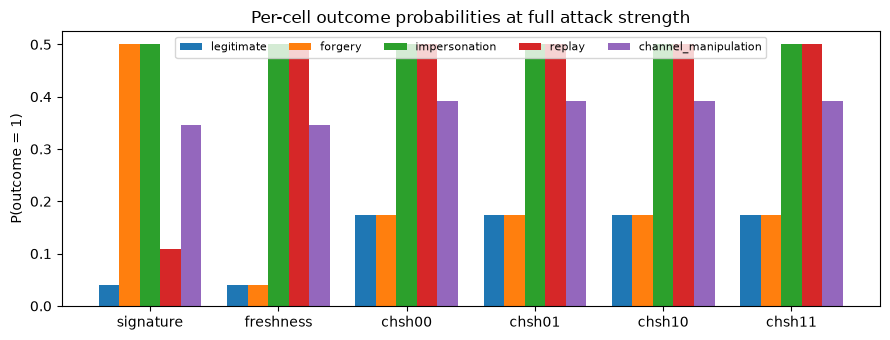

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.5))
w = 0.16
for i, h in enumerate(Hypothesis):
    ax.bar(np.arange(6) + (i - 2) * w, cell_probabilities(h, 1.0, params), w, label=h.value)
ax.set_xticks(range(6), CELLS); ax.set_ylabel('P(outcome = 1)'); ax.legend(fontsize=8, ncol=5)
ax.set_title('Per-cell outcome probabilities at full attack strength'); plt.tight_layout()
{h.value: round(expected_chsh(h, 1.0, params), 3) for h in Hypothesis}

## 2. One session on real Qiskit circuits

The `qiskit` backend runs every round as an Aer circuit: Bell pair, Bell measurement, `if_test` Pauli correction and projective verification.

In [3]:
t = simulate_session(Hypothesis.REPLAY, 1.0, seed=7, backend='qiskit')
v = Arbiter().verify(t)
print(v.decision, v.attribution.value)
for r in v.reasons: print(' -', r)
v.unified.posterior

REJECT replay
 - CHSH S=0.111 below 2.0: channel integrity not certified
 - unified GLRT 361.42 > 3.18 (alpha=0.01); most likely: replay


{'legitimate': 9.442697414914091e-157,
 'forgery': 5.893866533660734e-146,
 'impersonation': 4.507841746584735e-89,
 'replay': 1.0,
 'channel_manipulation': 3.679423524222488e-39}

## 3. Sequential test: raising the alarm early

Under the legitimate hypothesis the log-evidence stays below log(1/α) at every round with probability at least 1-α (Ville's inequality). Under an attack it crosses within a few dozen rounds.

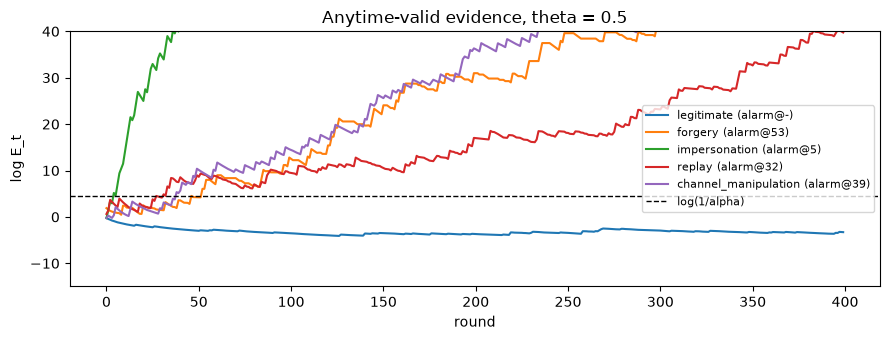

In [4]:
seq = SequentialDetector(params)
fig, ax = plt.subplots(figsize=(9, 3.5))
for h in Hypothesis:
    r = seq.evaluate(simulate_session(h, 0.5, seed=3))
    ax.plot(r.log_evidence[:400], label=f'{h.value} (alarm@{r.stopped_at if r.rejected else "-"})')
ax.axhline(np.log(100), color='k', ls='--', lw=1, label='log(1/alpha)')
ax.set_xlabel('round'); ax.set_ylabel('log E_t'); ax.set_ylim(-15, 40); ax.legend(fontsize=8)
ax.set_title('Anytime-valid evidence, theta = 0.5'); plt.tight_layout()

## 4. Accuracy across attack strengths

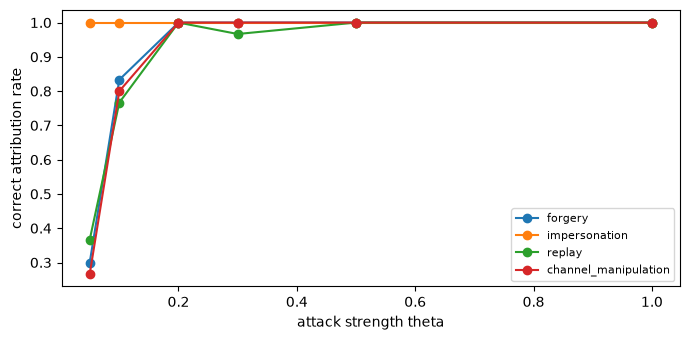

In [5]:
det = UnifiedDetector(params)
thetas = [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
acc = {}
for h in ATTACKS:
    acc[h.value] = [np.mean([det.evaluate(simulate_session(h, th, seed=900 + s)).attribution is h for s in range(30)]) for th in thetas]
fig, ax = plt.subplots(figsize=(7, 3.5))
for k, a in acc.items(): ax.plot(thetas, a, 'o-', label=k)
ax.set_xlabel('attack strength theta'); ax.set_ylabel('correct attribution rate'); ax.legend(fontsize=8)
plt.tight_layout()

## 5. Information-theoretic limits

The quantum Chernoff exponent bounds every possible measurement. For forgery, ARBITER's projective Pauli measurement reaches it exactly.

In [6]:
import pandas as pd
pd.DataFrame(attack_bounds(1.0)).set_index('attack')[['helstrom_error_single_round', 'quantum_chernoff', 'measured_chernoff', 'measurement_efficiency']].round(4)

,helstrom_error_single_round,quantum_chernoff,measured_chernoff,measurement_efficiency
attack,,,,
forgery,0.3850,0.0885,0.0885,1.0000
impersonation,0.2413,0.2272,0.1536,0.6760
replay,0.3390,0.1315,0.0644,0.4894
channel_manipulation,0.3275,0.1137,0.0796,0.6996


## 6. Tamper-evident audit ledger

In [7]:
import copy
from arbiter.audit_ledger import AuditLedger, LedgerKeys, verify_entries
ledger = AuditLedger(LedgerKeys.generate(hbs_height=4))
arb = Arbiter(ledger=ledger)
for h in (Hypothesis.LEGITIMATE, Hypothesis.FORGERY): arb.verify(simulate_session(h, seed=1))
print('clean:', ledger.verify().ok)
forged = copy.deepcopy(ledger.entries)
forged[2]['payload']['decision'] = 'ACCEPT'
print('tampered:', verify_entries(forged).problems)

clean: True
tampered: ['entry 2: entry hash mismatch (content altered)']


## 7. Trapped-ion calibration

The legitimate channel can be derived from ion-trap hardware figures.

In [8]:
from arbiter.noise import PRESETS
pd.DataFrame({k: p.visibility_budget() | {'visibility': p.visibility(), 'CHSH S': 2 * np.sqrt(2) * p.visibility()} for k, p in PRESETS.items()}).round(6)

,state_of_the_art_2025,prototype,conservative
ms_gate,0.999867,0.998667,0.986667
idle_dephasing,0.999867,0.997339,0.879154
motional_heating,0.999933,0.999867,0.998667
single_qubit_gates,0.999920,0.999600,0.996006
spam,0.999600,0.999000,0.994000
visibility,0.999187,0.994482,0.857638
CHSH S,2.826127,2.812821,2.425768


## 8. PKI quantum-risk scoring

In [9]:
from datetime import datetime, timedelta, timezone
from arbiter.pki_risk_scoring import assess_key
now = datetime.now(timezone.utc)
rows = [assess_key(a, b, expires=now + timedelta(days=d)).to_dict() for a, b, d in [('RSA', 1024, 365), ('RSA', 2048, 365), ('RSA', 4096, 365 * 12), ('ECDSA', 256, 90), ('Ed25519', None, 730), ('ML-DSA-65', None, 3650)]]
pd.DataFrame(rows)[['algorithm', 'key_bits', 'shor_logical_qubits', 'mosca_violated', 'score', 'level']]

,algorithm,key_bits,shor_logical_qubits,mosca_violated,score,level
0,RSA,1024.0,2051.0,False,95,critical
1,RSA,2048.0,4099.0,False,46,medium
2,RSA,4096.0,8195.0,True,85,high
3,ECDSA,256.0,2330.0,False,44,medium
4,Ed25519,255.0,2321.0,False,48,medium
5,ML-DSA-65,NaN,NaN,False,5,low
